# Learning to learn better by optimising batch size using Bayes Opt

In this tutorial, you will be using Bayes Opt to tune the batch size for a NN.

Please refer to the lecture slides for pseudo-code on Bayes Opt.

You will be using the segmentation network from last lab session and your goal would be to build a meta-learning system that can give you an optimal batch size.

You should use Bayes Opt along with the one or both networks that you trained in the last lab session to tune the batch size for one or both of the networks.

After training with the optimal batch size, compare your first model's performance with that of the one trained using the optimal batch size.

Batch size directly impacts the balance between training speed, generalization accuracy, and memory constraints. Too small of a batch size causes unstable training and thus poor perfomrnace, whereas too large of a batch size may take too long for training resulting in poor generalisability when trained with fixed compute budgets.

### Data download and extraction

In [1]:
!wget -O images_lab_data.zip https://github.com/s-sd/EMS741/raw/refs/heads/main/tutorials/images/images_lab_data.zip


import zipfile
import os

path_to_zip = r'images_lab_data.zip'
path_to_extract_to = r'./'

with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall(path_to_extract_to)


--2026-03-06 14:06:23--  https://github.com/s-sd/EMS741/raw/refs/heads/main/tutorials/images/images_lab_data.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/s-sd/EMS741/refs/heads/main/tutorials/images/images_lab_data.zip [following]
--2026-03-06 14:06:24--  https://raw.githubusercontent.com/s-sd/EMS741/refs/heads/main/tutorials/images/images_lab_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23924619 (23M) [application/zip]
Saving to: ‘images_lab_data.zip’

images_lab_data.zip 100%[===================>]  22.82M  --.-KB/s    in 0.08s   

2026-03-06 14:06:33 (277 MB/s) - ‘images_lab

In [2]:
!ls

# we are interested in 'images' and 'masks'

images	images_lab_data.zip  masks  sample_data


### Data checks

Before you proceed with building your segmentation system, load in a single image and corresponding mask to verify that they are paired correctly. And to check their shapes etc. Hint: use the matplotlib imread function.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

images_file_names = np.array(sorted(os.listdir('images')))
masks_file_names = np.array(sorted(os.listdir('masks')))

#shuffle the image and masks using the same order
shuffle_indexes = np.array(np.random.permutation(len(images_file_names)), dtype=np.int32)

images_file_names_shuffled = images_file_names[shuffle_indexes]
masks_file_names_shuffled = masks_file_names[shuffle_indexes]

print(images_file_names_shuffled[0], masks_file_names_shuffled[0])

sample_199_slice_009.png sample_199_slice_009.png


images/sample_284_slice_013.png masks/sample_284_slice_013.png


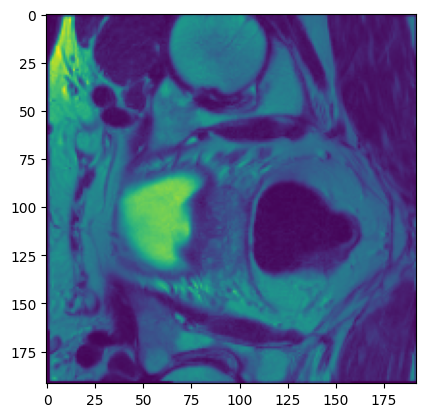

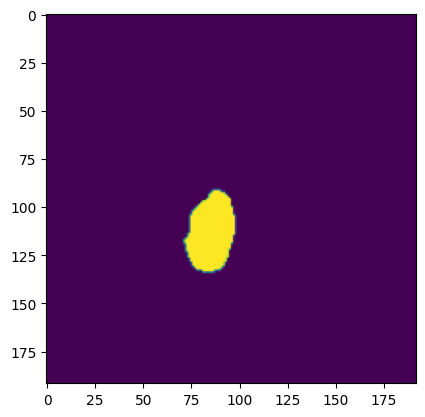

In [4]:
sample_number_to_plot = 10

image_path = os.path.join(r'images', images_file_names_shuffled[sample_number_to_plot])
mask_path = os.path.join(r'masks', masks_file_names_shuffled[sample_number_to_plot])

print(image_path, mask_path)

image = plt.imread(image_path)
mask = plt.imread(mask_path)

plt.imshow(image)

plt.figure()
plt.imshow(mask)

In [5]:
print(np.amin(image), np.amax(image))
print(np.amin(mask), np.amax(mask))
print(image.shape, mask.shape)

# this is what we can use to quickly get a classification label
# if the sum of all pixels in the mask is >1 then prostate exists
# if the sum is 0 then prostate does not exist
print(int(np.sum(mask, axis=None)>1))

0.0 1.0
0.0 1.0
(192, 192) (192, 192)
1


### Classification NN

This is the classification NN from last lab.

In [6]:
# python generator for classification

def my_classification_data_generator(batch_size, x_shape, y_shape, file_names, images_file_path, masks_file_path):

  while True:

    batch_x = np.zeros((batch_size, *x_shape))
    batch_y = np.zeros((batch_size, *y_shape))

    for i in range(batch_size):

      index = np.random.randint(len(file_names))

      image = plt.imread(os.path.join(images_file_path, file_names[index]))

      mask = plt.imread(os.path.join(masks_file_path, file_names[index]))
      classification = int(np.sum(mask, axis=None)>1)

      batch_x[i] = image
      batch_y[i] = classification

    batch_x = np.expand_dims(batch_x, axis=-1)

    yield batch_x, batch_y


In [7]:
import tensorflow as tf

# build a simple convolutional alexnet style architecture

image_shape = [*image.shape, 1]
print(image_shape)


def build_minimal_alexnet(input_shape=image_shape):

    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(64, (11, 11), strides=4, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2)(x)
    x = tf.keras.layers.Conv2D(192, (5, 5), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2)(x)
    x = tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


classification_model = build_minimal_alexnet()

# USE SGD OPTIMIZER; because Adam has a state and we want to train from scratch for each performance evaluator run!

classification_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
classification_model.summary()

[192, 192, 1]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 23, 23, 192)    │       307,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 384)    │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,141,953 (19.61 MB)

 Trainable params: 5,141,953 (19.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# split file names into relevant sets

train_val_test_ratio = [0.6, 0.2, 0.2]

num_files = len(images_file_names_shuffled)

train_val_test_ratio = [0.6, 0.2, 0.2]

train_index_start = 0
train_index_end = int(train_val_test_ratio[0] * num_files)

val_index_start = train_index_end
val_index_end = val_index_start + int(train_val_test_ratio[1] * num_files)

test_index_start = val_index_end
test_index_end = test_index_start + int(train_val_test_ratio[2] * num_files)

train_file_names = images_file_names_shuffled[train_index_start:train_index_end]
val_file_names = images_file_names_shuffled[val_index_start:val_index_end]
test_file_names = images_file_names_shuffled[test_index_start:test_index_end]


Now we need to create the performance evaluator function and then use that with Bayes opt. Then once we have found the optimal batch size, we can use that for training.

In [9]:
!pip install scikit-optimize

In [10]:
import numpy as np
from skopt import gp_minimize
from skopt.space import Integer


def round_to_multiple_of_8(x):
    return int(np.round(x / 8) * 8)

x_shape = image.shape
y_shape = [1]
images_file_path = r'images'
masks_file_path = r'masks'

# Helper: create generators
def make_generators(batch_size):

    train_gen = my_classification_data_generator(
        batch_size,
        x_shape,
        y_shape,
        train_file_names,
        images_file_path,
        masks_file_path
    )

    val_gen = my_classification_data_generator(
        batch_size,
        x_shape,
        y_shape,
        val_file_names,
        images_file_path,
        masks_file_path
    )

    return train_gen, val_gen


# Save initial weights
initial_weights = classification_model.get_weights()


# Objective for Bayesian optimization
def performance_evaluator(params):

    batch_size = round_to_multiple_of_8(params[0])
    print('Trying Bacth Size: ', batch_size)

    # reset weights
    classification_model.set_weights(initial_weights)

    # recreate generators with this batch size
    train_gen, val_gen = make_generators(batch_size)

    history = classification_model.fit(
        train_gen,
        steps_per_epoch=100,
        epochs=1,
        validation_data=val_gen,
        validation_steps=8,
        verbose=1
    )

    val_loss = history.history['val_loss'][-1]

    print(f"batch_size={batch_size}, val_loss={val_loss}")

    return val_loss


# Run Bayesian optimization
result = gp_minimize(
    performance_evaluator,
    [Integer(8, 256), (1,)],  # range and shape of input
    acq_func='EI',
    n_calls=4,        # these are just examples, for a real run use >=8
    n_random_starts=3
)

best_batch_size = round_to_multiple_of_8(result.x[0])

print("Best batch size:", best_batch_size)


# Final training with optimal batch size
classification_model.set_weights(initial_weights)

train_gen, val_gen = make_generators(best_batch_size)

history = classification_model.fit(
    train_gen,
    steps_per_epoch=128,
    epochs=4,          # in a real run this would be higher
    validation_data=val_gen,
    validation_steps=8,
    verbose=1
)

Trying Bacth Size:  256
100/100 ━━━━━━━━━━━━━━━━━━━━ 101s 837ms/step - accuracy: 0.7473 - loss: 0.5967 - val_accuracy: 0.8281 - val_loss: 0.4648
batch_size=256, val_loss=0.4648131728172302
Trying Bacth Size:  104
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step - accuracy: 0.7535 - loss: 0.5948 - val_accuracy: 0.8486 - val_loss: 0.4533
batch_size=104, val_loss=0.4532721936702728
Trying Bacth Size:  72
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.7524 - loss: 0.5974 - val_accuracy: 0.8403 - val_loss: 0.4388
batch_size=72, val_loss=0.4387662708759308
Trying Bacth Size:  72
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.7579 - loss: 0.5874 - val_accuracy: 0.8299 - val_loss: 0.4577
batch_size=72, val_loss=0.4577176868915558
Best batch size: 72
Epoch 1/4
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - accuracy: 0.7484 - loss: 0.5883 - val_accuracy: 0.8333 - val_loss: 0.4627
Epoch 2/4
128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.7809 - loss: 0.5226 - val_accurac

### Now let's do the same for the segmentation model

In [11]:
# data generator for segmentation

def my_segmentation_data_generator(batch_size, x_shape, y_shape, file_names, images_file_path, masks_file_path):

  while True:

    batch_x = np.zeros((batch_size, *x_shape))
    batch_y = np.zeros((batch_size, *y_shape))

    for i in range(batch_size):

      index = np.random.randint(len(file_names))

      image = plt.imread(os.path.join(images_file_path, file_names[index]))
      mask = plt.imread(os.path.join(masks_file_path, file_names[index]))

      batch_x[i] = image
      batch_y[i] = mask

    batch_x = np.expand_dims(batch_x, axis=-1)
    batch_y = np.expand_dims(batch_y, axis=-1)

    yield batch_x, batch_y

In [12]:
# build a Unet model

image_shape = [*image.shape, 1]
print(image_shape)

def build_simple_unet(input_shape=image_shape, out_channels=1):

    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    s1 = x # skip connection
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    s2 = x
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    s3 = x
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)

    x = tf.keras.layers.UpSampling2D()(x)
    x = tf.keras.layers.Concatenate()([x, s3])
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)

    x = tf.keras.layers.UpSampling2D()(x)
    x = tf.keras.layers.Concatenate()([x, s2])
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)

    x = tf.keras.layers.UpSampling2D()(x)
    x = tf.keras.layers.Concatenate()([x, s1])
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)

    outputs = tf.keras.layers.Conv2D(out_channels, 1, padding='same', activation='sigmoid' if out_channels == 1 else 'softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


segmentation_model = build_simple_unet(input_shape=image_shape, out_channels=1)

# USE SGD OPTIMIZER; because Adam has a state and we want to train from scratch for each performance evaluator run!

segmentation_model.compile(optimizer='sgd', loss='binary_crossentropy')
segmentation_model.summary()

[192, 192, 1]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 192, 192,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 192, 192,  │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 96, 96,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 96, 96,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 96, 96,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 48, 48,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 48, 48,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 48, 48,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 24, 24,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 24, 24,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 24, 24,    │    590,080 │ conv2d_10[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 48, 48,    │          0 │ conv2d_11[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 48,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 48, 48,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 48, 48,    │    147,584 │ conv2d_12[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 96, 96,    │          0 │ conv2d_13[0][0] 

 Total params: 1,946,305 (7.42 MB)

 Trainable params: 1,946,305 (7.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:

def round_to_multiple_of_8(x):
    return int(np.round(x / 8) * 8)

x_shape = image.shape
y_shape = mask.shape
images_file_path = r'images'
masks_file_path = r'masks'

# Helper: create generators
def make_generators(batch_size):

    train_gen = my_segmentation_data_generator(
        batch_size,
        x_shape,
        y_shape,
        train_file_names,
        images_file_path,
        masks_file_path
    )

    val_gen = my_segmentation_data_generator(
        batch_size,
        x_shape,
        y_shape,
        val_file_names,
        images_file_path,
        masks_file_path
    )

    return train_gen, val_gen


# Save initial weights
initial_weights = segmentation_model.get_weights()


# Objective for Bayesian optimization
def performance_evaluator(params):

    batch_size = round_to_multiple_of_8(params[0])
    print('Trying Bacth Size: ', batch_size)

    # reset weights
    segmentation_model.set_weights(initial_weights)

    # recreate generators with this batch size
    train_gen, val_gen = make_generators(batch_size)

    history = segmentation_model.fit(
        train_gen,
        steps_per_epoch=100,
        epochs=1,
        validation_data=val_gen,
        validation_steps=8,
        verbose=1
    )

    val_loss = history.history['val_loss'][-1]

    print(f"batch_size={batch_size}, val_loss={val_loss}")

    return val_loss


# Run Bayesian optimization
result = gp_minimize(
    performance_evaluator,
    [Integer(8, 128), (1,)],  # max 128, as >160 results in OOM error
    acq_func='EI',
    n_calls=4,      # these are just examples, for a real run use >=8
    n_random_starts=3
)

best_batch_size = round_to_multiple_of_8(result.x[0])

print("Best batch size:", best_batch_size)


# Final training
segmentation_model.set_weights(initial_weights)

train_gen, val_gen = make_generators(best_batch_size)

history = segmentation_model.fit(
    train_gen,
    steps_per_epoch=128,
    epochs=4,
    validation_data=val_gen,
    validation_steps=8,
    verbose=1
)

Trying Bacth Size:  88
100/100 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - loss: 0.5121 - val_loss: 0.1015
batch_size=88, val_loss=0.10148824006319046
Trying Bacth Size:  24
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 317ms/step - loss: 0.5122 - val_loss: 0.1008
batch_size=24, val_loss=0.10078758001327515
Trying Bacth Size:  56
100/100 ━━━━━━━━━━━━━━━━━━━━ 135s 724ms/step - loss: 0.5118 - val_loss: 0.1025
batch_size=56, val_loss=0.10247009992599487
Trying Bacth Size:  16
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 207ms/step - loss: 0.5108 - val_loss: 0.1053
batch_size=16, val_loss=0.10529258847236633
Best batch size: 24
Epoch 1/4
128/128 ━━━━━━━━━━━━━━━━━━━━ 32s 251ms/step - loss: 0.4667 - val_loss: 0.1055
Epoch 2/4
128/128 ━━━━━━━━━━━━━━━━━━━━ 31s 246ms/step - loss: 0.1008 - val_loss: 0.1047
Epoch 3/4
128/128 ━━━━━━━━━━━━━━━━━━━━ 32s 246ms/step - loss: 0.0986 - val_loss: 0.1046
Epoch 4/4
128/128 ━━━━━━━━━━━━━━━━━━━━ 32s 248ms/step - loss: 0.0993 - val_loss: 0.1016
